In [1]:
import dask
# dask.config.set(scheduler="synchronous")

from toolviper.dask.client import local_client

viper_client = local_client(cores=4, memory_limit="4GB")
viper_client

[2026-03-20 12:17:03,476]  WARNING      client:  It is recommended that the local cache directory be set using the dask_local_dir parameter. 
[2026-03-20 12:17:04,634]     INFO      client:  Client <MenrvaClient: 'tcp://127.0.0.1:60857' processes=4 threads=4, memory=14.90 GiB> 


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:60857,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 4
Started: Just now,Total memory: 14.90 GiB
Comm: tcp://127.0.0.1:60871,Total threads: 1
Dashboard: http://127.0.0.1:60873/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:60860,


## Download Dataset

In [2]:
from xradio.measurement_set import open_processing_set
from toolviper.utils.data import download, update
update()

download(file="twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr")
ps_xdt = open_processing_set("twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr")

download(file="twhya_selfcal_5chans_lsrk_xx_compare_weights.ps.zarr")
ps_single_pol_xdt = open_processing_set("twhya_selfcal_5chans_lsrk_xx_compare_weights.ps.zarr")


download(file="3c286_Band6_5chans_lsrk_compare_weights.ps.zarr")
ps_full_pol_xdt = open_processing_set("3c286_Band6_5chans_lsrk_compare_weights.ps.zarr")


ps_xdt.xr_ps.summary()

[2026-03-20 12:17:05,243]     INFO      client:  Updating file metadata information... 


/Users/jsteeb/miniforge3/envs/zinc/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[2026-03-20 12:17:05,464]     INFO      client:  Initializing download... 
[2026-03-20 12:17:05,465]     INFO      client:  File already exists: /Users/jsteeb/Dropbox/viper_dev/astroviper/docs/tutorials/twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr 
[2026-03-20 12:17:05,850]     INFO      client:  Initializing download... 
[2026-03-20 12:17:05,851]     INFO      client:  File already exists: /Users/jsteeb/Dropbox/viper_dev/astroviper/docs/tutorials/twhya_selfcal_5chans_lsrk_xx_compare_weights.ps.zarr 
[2026-03-20 12:17:05,873]     INFO      client:  Initializing download... 
[2026-03-20 12:17:05,874]     INFO      client:  File already exists: /Users/jsteeb/Dropbox/viper_dev/astroviper/docs/tutorials/3c286_Band6_5chans_lsrk_compare_weights.ps.zarr 


,name,scan_intents,shape,execution_block_UID,polarization,scan_name,spw_name,spw_intents,field_name,source_name,line_name,field_coords,session_reference_UID,scheduling_block_UID,project_UID,start_frequency,end_frequency
0,twhya_selfcal_5chans_lsrk_0,[OBSERVE_TARGET#ON_SOURCE],"(270, 171, 5, 2)",---,"[XX, YY]","[12, 16, 20, 24, 28, 36]",ALMA_RB_07#BB_2#SW-01#FULL_RES_0,UNSPECIFIED,[TW Hya_5],[3c279_4],[],"[fk5, 11h01m51.80s, -34d42m17.37s]",---,---,---,3.727306e+11,3.727330e+11


In [ ]:

%load_ext autoreload
%autoreload 2

# import dask
# dask.config.set(scheduler="synchronous")

# from toolviper.dask.client import local_client

# viper_client = local_client(cores=4, memory_limit="4GB")
# viper_client

#log_level = "DEBUG" 
log_level = "INFO" 
log_to_file = False
log_params = { "logger_name": "main",
            "log_to_term": True,
            "log_level": log_level,
            "log_to_file": log_to_file,
            "log_file": "client.log",
            }

worker_logs = { "logger_name": "worker",
            "log_to_term": True,
            "log_level": log_level,
            "log_to_file": log_to_file,
            "log_file": "client_worker.log",
            }


from toolviper.dask.client import local_client

viper_client = local_client(cores=1, memory_limit="18GB", log_params=log_params, worker_log_params=worker_logs)
viper_client

import os
import numpy as np
from xradio.measurement_set import open_processing_set
from astroviper.distributed.imaging.image_cube_single_field import image_cube_single_field
from xradio.image import make_empty_sky_image

os.system("rm -rf twhya_selfcal_5chans_lsrk_compare_weights.img.zarr")
ps_single_pol_xdt = open_processing_set("twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr")
combined_field_and_source_xds = ps_single_pol_xdt.xr_ps.get_combined_field_and_source_xds()
center_field_name = combined_field_and_source_xds.attrs["center_field_name"]
phase_direction = (
    combined_field_and_source_xds.FIELD_PHASE_CENTER_DIRECTION.sel(
        field_name=center_field_name
    )
)

#print(ps_single_pol_xdt.xr_ps.get_freq_axis())

empty_img_xds = make_empty_sky_image(
        phase_center=phase_direction.values,
        image_size=[250,250],
        cell_size=np.array([-0.1,0.1]) * np.pi/(180 * 3600),
        frequency_coords=ps_single_pol_xdt.xr_ps.get_freq_axis().values,
        pol_coords=["I"],
        time_coords=[0],
    )

# image_cube_single_field

imaging_metadata_dict = image_cube_single_field(
    ps_store = "twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr",
    image_store = "twhya_selfcal_5chans_lsrk_compare_weights.img.zarr",
    image_params={
        "image_size": [250, 250],
        "cell_size": np.array([0.1, 0.1]) * np.pi/(180 * 3600),
        "phase_direction": phase_direction.values,
        "frequency_coords": ps_single_pol_xdt.xr_ps.get_freq_axis().values,
        "polarization_coords": ["I","Q"],
        "time_coords": [0],
        "fft_padding": 1.2,
        "cpp_gridder": False
    },
    imaging_weights_params={
        "weighting": "briggs",
        "robust": 0.5,
    },
    # imaging_weights_params={
    #     "weighting": "natural",
    # },
    iteration_control_params={
        "niter": 0,
        "nmajor": 0,
        "threshold": 0.0,
        "gain": 0.1,
        "cyclefactor": 1.5,
        "cycleniter": 10,
    },
    gridder="prolate_spheroidal",
    deconvolver="hogbom",
    fft_padding="1.0",
    scan_intents="OBSERVE_TARGET#ON_SOURCE",
    #image_data_variables_keep=["sky", "point_spread_function", "primary_beam"],
    # image_data_variables_keep=["sky_model", "sky_residual", "sky_deconvolved", "point_spread_function", "primary_beam"],
    image_data_variables_keep=["sky_residual", "point_spread_function", "primary_beam", "beam_fit_params_point_spread_function"],
    #image_data_variables_keep=[ "sky", "point_spread_function", "primary_beam"],
    processing_set_data_group_name="base",
    double_precision=True,
    thread_info=None,
    n_chunks=None,
    overwrite=True,
)
imaging_metadata_dict

[2026-03-24 15:04:09,802]  WARNING        main:  It is recommended that the local cache directory be set using the dask_local_dir parameter. 
[2026-03-24 15:04:10,807]     INFO        main:  Client <MenrvaClient: 'tcp://127.0.0.1:57459' processes=1 threads=1, memory=16.76 GiB> 
[2026-03-24 15:04:12,060]     INFO        main:  Time to create empty image xds: 0.0010788440704345703 seconds 
[2026-03-24 15:04:12,068]     INFO        main:  Time to write empty image to disk: 0.0071659088134765625 seconds 


INFO:main:Time to write empty image to disk: 0.0071659088134765625 seconds


[2026-03-24 15:04:12,068]     INFO        main:  Memory required for a single frequency channel: 0.005029141902923584 GiB 


INFO:main:Memory required for a single frequency channel: 0.005029141902923584 GiB


[2026-03-24 15:04:12,069]     INFO        main:  Thread info {'n_threads': 1, 'memory_per_thread': 16.763806343078613} 


...

[2026-03-24 15:04:12,147]     INFO        main:  Time to create map reduce graph: 0.00019097328186035156 seconds 


INFO:main:Time to create map reduce graph: 0.00019097328186035156 seconds


[2026-03-24 15:04:12,152]     INFO        main:  Time to generate dask graph: 0.0027129650115966797 seconds 


INFO:main:Time to generate dask graph: 0.0027129650115966797 seconds
2026-03-24 15:04:12,821 - distributed.worker - ERROR - Compute Failed
Key:       wrap_image_cube_single_field_node_task-38d7c943-8584-4fcc-bc30-35b76aa3511a
State:     executing
Task:  <Task 'wrap_image_cube_single_field_node_task-38d7c943-8584-4fcc-bc30-35b76aa3511a' wrap_image_cube_single_field_node_task(...)>
Exception: "FileNotFoundError(2, 'No such file or directory')"
Traceback: '  File "/Users/jsteeb/Dropbox/viper_dev/astroviper/src/astroviper/distributed/imaging/image_cube_single_field.py", line 333, in wrap_image_cube_single_field_node_task\n    result = image_cube_single_field_node_task(input_params, ps_iter, img_xds)\n  File "/Users/jsteeb/Dropbox/viper_dev/astroviper/src/astroviper/task/imaging/image_cube_single_field_node_task.py", line 16, in image_cube_single_field_node_task\n    img_xds, return_df = residual_cycle_cube_single_field_node_task(\n                         ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jsteeb/Dropbox/viper_dev/astroviper/src/astroviper/core/imaging/check_imaging_parameters.py'

In [4]:
import xarray as xr
img_xds = xr.open_zarr("twhya_selfcal_5chans_lsrk_compare_weights.img.zarr")
img_xds

<xarray.Dataset> Size: 15MB
Dimensions:                (time: 1, frequency: 5, polarization: 2, l: 250,
                            m: 250, beam_params_label: 3)
Coordinates:
  * time                   (time) float64 8B 0.0
  * frequency              (frequency) float64 40B 3.727e+11 ... 3.727e+11
    velocity               (frequency) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
  * polarization           (polarization) <U1 8B 'I' 'Q'
  * l                      (l) float64 2kB 6.06e-05 6.012e-05 ... -6.012e-05
  * m                      (m) float64 2kB -6.06e-05 -6.012e-05 ... 6.012e-05
  * beam_params_label      (beam_params_label) <U5 60B 'major' 'minor' 'pa'
Data variables:
    POINT_SPREAD_FUNCTION  (time, frequency, polarization, l, m) float64 5MB dask.array<chunksize=(1, 1, 2, 250, 250), meta=np.ndarray>
    PRIMARY_BEAM           (time, frequency, polarization, l, m) float64 5MB dask.array<chunksize=(1, 1, 2, 250, 250), meta=np.ndarray>
    SKY_RESIDUAL           (time, frequency, polarization, l, m) float64 5MB dask.array<chunksize=(1, 1, 2, 250, 250), meta=np.ndarray>
Attributes:
    coordinate_system_info:  {'native_pole_direction': {'attrs': {'frame': 'N...
    data_groups:             {'base': {}}
    type:                    image

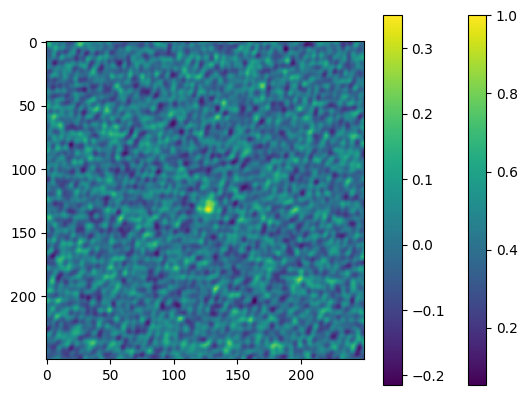

In [5]:
import xarray as xr
img_xds = xr.open_zarr("twhya_selfcal_5chans_lsrk_compare_weights.img.zarr")
img_xds

import matplotlib.pyplot as plt
plt.imshow(img_xds.PRIMARY_BEAM.isel(frequency=0, polarization=1, time=0).values)
plt.colorbar()

# import matplotlib.pyplot as plt
# plt.imshow(img_xds.POINT_SPREAD_FUNCTION.isel(frequency=0, polarization=1, time=0).values)
# plt.colorbar()

import matplotlib.pyplot as plt
plt.imshow(img_xds.SKY_RESIDUAL.isel(frequency=3, polarization=0, time=0).values)
plt.colorbar()

In [23]:
from xradio.measurement_set import open_processing_set
from toolviper.utils.data import download, update
from xarray.core.indexing import ExplicitlyIndexed
import xarray as xr
update()

download(file="twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr")
ps_xdt = xr.open_datatree("twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr",chunks=None)

for node in ps_xdt.items():
    test = node[1].ds.VISIBILITY + 1
    print(isinstance(node[1].ds.VISIBILITY.variable._data, xr.core.indexing.LazilyIndexedArray))
    print(isinstance(node[1].ds.VISIBILITY.variable._data, ExplicitlyIndexed))
    print("*******")

for node in ps_xdt.items():
    #print(node[1].ds.VISIBILITY.load())
    test = node[1].ds.VISIBILITY 
    test2 = node[1].ds.VISIBILITY + 1
    #print(isinstance(node[1].ds.VISIBILITY.variable._data, xr.core.indexing.LazilyIndexedArray))
    print(isinstance(node[1].ds.VISIBILITY.variable._data, ExplicitlyIndexed))
    print(test.variable._data, ExplicitlyIndexed)
    print(test2.variable._data, ExplicitlyIndexed)
    print("*******")

[2026-03-25 09:58:58,545]     INFO   toolviper:  Updating file metadata information... 


/Users/jsteeb/miniforge3/envs/zinc/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[2026-03-25 09:58:58,730]     INFO   toolviper:  Initializing download... 
[2026-03-25 09:58:58,731]     INFO   toolviper:  File already exists: /Users/jsteeb/Dropbox/viper_dev/astroviper/docs/tutorials/twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr 
False
True
*******
True
MemoryCachedArray(array=NumpyIndexingAdapter(array=array([[[[  6.2508855 -6.81403065e+00j,   6.9959764 +2.14600468e+00j],
         [ -0.374745  +1.53494053e+01j,  -6.9488974 -1.14393473e+01j],
         [ -7.273557  -2.64286661e+00j, -14.199694  +3.91854358e+00j],
         [-14.689277  -5.86778545e+00j,  -3.2487538 +5.99041748e+00j],
         [  6.711029  +5.26545143e+00j,  19.843332  +3.31886911e+00j]],

        [[ -0.10323621-2.43706155e+00j,  -5.0210586 +3.31750774e+00j],
         [ -8.083067  +9.59750175e+00j, -12.300367  -2.47301364e+00j],
         [ 17.198696  -5.16772175e+00j, -15.56432   -1.28117857e+01j],
         [-12.861429  +9.35210323e+00j,   9.257043  +5.27677011e+00j],
         [-15.984402  +2.08671

In [26]:
from xradio.measurement_set import open_processing_set
from toolviper.utils.data import download, update
from xarray.core.indexing import ExplicitlyIndexed
import xarray as xr
update()

download(file="twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr")
ps_xdt = xr.open_datatree("twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr",chunks=None)

for ms_xdt in ps_xdt.items():
    print(ms_xdt[0])

[2026-03-26 16:34:16,312]     INFO   toolviper:  Updating file metadata information... 


/Users/jsteeb/miniforge3/envs/zinc/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[2026-03-26 16:34:16,455]     INFO   toolviper:  Initializing download... 
[2026-03-26 16:34:16,456]     INFO   toolviper:  File already exists: /Users/jsteeb/Dropbox/viper_dev/astroviper/docs/tutorials/twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr 
twhya_selfcal_5chans_lsrk_0
